In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [3]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [4]:
# quedarnos con el periodo para el que tenemos las variables del LLM

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [5]:
df["fecha"].describe()

count                               79
mean     2025-02-28 07:53:55.443037952
min                2025-01-02 00:00:00
25%                2025-01-29 12:00:00
50%                2025-02-26 00:00:00
75%                2025-03-29 12:00:00
max                2025-04-30 00:00:00
Name: fecha, dtype: object

In [6]:
df = df.rename(columns={
    "merval_apertura_+2": "merval",
})

In [7]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [8]:
# chequeo de cuantos NAs tenemos en cada columna
pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
merval_cierre,0,0.0
merval_maximo,0,0.0
emae_tendencia_ciclo_ma_5,0,0.0
badlar_ma_3,0,0.0
...,...,...
m2_diff3,0,0.0
base_monetaria_diff10,0,0.0
tasa_prestamos_personales_hp_rm20,0,0.0
prestamos_privados_ars_diff1,0,0.0


In [9]:
# Eliminar filas con NaN creadas por los lags (las primeras 5 si usamos hasta lags de 5 dias)
df = df.dropna().copy()

In [10]:
y = df["merval"]
X = df.drop(columns=["merval","fecha"])

print(f"Dataset original: {X.shape[0]} filas x {X.shape[1]} features")
print(f"Ratio features/observaciones: {X.shape[1]/X.shape[0]:.2f} (ideal: < 0.1)")
print("\n⚠️ PROBLEMA: Más features que observaciones causa overfitting severo")

Dataset original: 79 filas x 60 features
Ratio features/observaciones: 0.76 (ideal: < 0.1)

⚠️ PROBLEMA: Más features que observaciones causa overfitting severo


## Feature Selection (Reducción de dimensionalidad)

In [11]:
# ESTRATEGIA 1: Correlación con el target
# Seleccionar solo features con correlación absoluta significativa

correlations = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 20 features por correlación con target:")
print(correlations.head(20))

# Regla práctica: N_features ≈ sqrt(N_observaciones) o N/3 como máximo
# Con 79 observaciones totales: sqrt(79) ≈ 9, pero usaremos un poco más
n_features_to_select = 12  # Compromiso entre información y overfitting

selected_features = correlations.head(n_features_to_select).index.tolist()
print(f"\n✓ Seleccionadas {n_features_to_select} features (de {X.shape[1]} originales)")
print(f"Features seleccionadas: {selected_features}")

X = X[selected_features]

Top 20 features por correlación con target:
merval_cierre                     0.932267
merval_maximo                     0.913421
emae_tendencia_ciclo_ma_5         0.849511
emae_tendencia_ciclo_lag2         0.835678
merval_maximo_hp_ema20            0.678890
m2_transaccional_std20            0.603450
emae_original_std20               0.594616
m2_std20                          0.573571
emae_desestacionalizado_std20     0.571797
merval_apertura_std20             0.570243
merval_cierre_std20               0.536406
emae_original_lag1                0.474596
badlar_spec_centroid              0.469823
m1_std20                          0.449058
emae_original_lag2                0.432777
badlar_hp_ema20                   0.428191
merval_maximo_pct10               0.426153
inflacion_lag2                    0.417601
merval_maximo_diff10              0.414743
tasa_prestamos_personales_ma_5    0.398209
dtype: float64

✓ Seleccionadas 12 features (de 60 originales)
Features seleccionadas: ['merval_

## Train-Test Split

In [12]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\n✓ Ratio mejorado - Features/Observaciones train: {X_train.shape[1]/X_train.shape[0]:.2f}")

X_train shape: (63, 12)
X_test shape: (16, 12)

✓ Ratio mejorado - Features/Observaciones train: 0.19


## Funcion objetivo para Optuna y Cross-Validation

In [13]:
max_lag = 5 # por el moving average 5

In [14]:
def objective(trial):
    # Espacios de búsqueda ajustados para ~63 filas de entrenamiento y ~12 features
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,

        # Aprendizaje: mayor learning rate con pocos datos
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),

        # Complejidad del árbol: MUY REDUCIDA para evitar overfitting
        "num_leaves": trial.suggest_int("num_leaves", 3, 10),  # Árboles muy simples
        "max_depth": trial.suggest_int("max_depth", 2, 4),  # Poco profundos

        # Mínimos ajustados a dataset pequeño
        "min_child_samples": trial.suggest_int("min_child_samples", 3, 10),

        # Regularizaciones L1/L2 - FUERTES para evitar overfitting
        "lambda_l1": trial.suggest_float("lambda_l1", 0.5, 15.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.5, 25.0, log=True),

        # min_split_gain más alto para evitar splits innecesarios
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 3.0),

        # Submuestreo
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        # Pocos árboles con dataset pequeño
        "n_estimators": trial.suggest_int("n_estimators", 10, 100),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes (evitan configuraciones inválidas) ---------
    eff = params.copy()

    # Alinear num_leaves con max_depth: num_leaves <= 2**max_depth cuando max_depth>0
    if eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Activar frecuencia de bagging si hay subsample<1
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1

    # --------------------------------------------------------------------------

    # Cross validation con MENOS splits para dataset pequeño
    n_splits = 3  # Solo 3 folds con 63 filas
    test_size = 8  # ~2 semanas de validación
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=max_lag)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
        )

        # Predicción usando los árboles óptimos según early stopping
        preds = model.predict(X_va, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_va, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))

In [15]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval")
study.optimize(objective, n_trials=30, show_progress_bar=True)  # Reducido de 50 a 30 trials

print("Mejores hiperparámetros:", study.best_params)
print("Mejor RMSE CV promedio:", study.best_value)

[I 2025-11-15 11:40:14,935] A new study created in memory with name: lgbm_merval


  0%|          | 0/30 [00:00<?, ?it/s]

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-15 11:40:14,985] Trial 0 finished with value: 172232.78636167216 and parameters: {'learning_rate': 0.014022586618133196, 'num_leaves': 3, 'max_depth': 2, 'min_child_samples': 8, 'lambda_l1': 0.7974036427554789, 'lambda_l2': 0.8757911985220973, 'min_split_gain': 2.720856736226551, 'subsample': 0.8562917108199231, 'colsample_bytree': 0.7120354112111873, 'n_estimators': 49}. Best is trial 0 with value: 172232.78636167216.
[I 2025-11-15 11:40:15,031] Trial 1 finished with value: 166398.36290086745 and parameters: {'learning_rate': 0.02700250607330114, 'num_leaves': 6, 'max_depth': 4, 'min_child_samples': 4, 'lambda_l1': 3.8140021076849897, 'lambda_l2': 16.3957015497357, 'min_split_gain': 2.526470826772759, 'subsample': 0.9992568325002703, 'colsample_bytree': 0.9538161152361055, 'n_estimators': 60}. Best is trial 1 with value: 166398.36290086745.
[I 2025-11-15 11:40:15,064] Trial 2 finished with value: 129885.14060297167 and parameters: {'learning_rate': 0.13740144341156077, 'num

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

...

[I 2025-11-15 11:40:16,426] Trial 22 finished with value: 99464.03256395069 and parameters: {'learning_rate': 0.14498975462529792, 'num_leaves': 5, 'max_depth': 2, 'min_child_samples': 4, 'lambda_l1': 11.321497431295139, 'lambda_l2': 2.730366630265685, 'min_split_gain': 1.9802855085111215, 'subsample': 0.8232599841625703, 'colsample_bytree': 0.7172347102972961, 'n_estimators': 83}. Best is trial 21 with value: 97251.41392426245.
[I 2025-11-15 11:40:16,503] Trial 23 finished with value: 108344.20727019402 and parameters: {'learning_rate': 0.08059769440491556, 'num_leaves': 3, 'max_depth': 2, 'min_child_samples': 3, 'lambda_l1': 5.841603721789693, 'lambda_l2': 5.547111963928834, 'min_split_gain': 1.5951814017469717, 'subsample': 0.7661600662156893, 'colsample_bytree': 0.7262907175725176, 'n_estimators': 69}. Best is trial 21 with value: 97251.41392426245.
[I 2025-11-15 11:40:16,578] Trial 24 finished with value: 99384.62252379087 and parameters: {'learning_rate': 0.1321005309659205, 'num

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-15 11:40:16,680] Trial 25 finished with value: 101860.74306840134 and parameters: {'learning_rate': 0.09417007783058312, 'num_leaves': 7, 'max_depth': 2, 'min_child_samples': 5, 'lambda_l1': 5.302115029774592, 'lambda_l2': 3.3709787654287764, 'min_split_gain': 2.9371015693059865, 'subsample': 0.834327117655949, 'colsample_bytree': 0.669984748980822, 'n_estimators': 79}. Best is trial 21 with value: 97251.41392426245.
[I 2025-11-15 11:40:16,769] Trial 26 finished with value: 105748.3690558789 and parameters: {'learning_rate': 0.15506640978610625, 'num_leaves': 5, 'max_depth': 3, 'min_child_samples': 4, 'lambda_l1': 0.5347425809068787, 'lambda_l2': 5.101439784696308, 'min_split_gain': 1.6278014036051478, 'subsample': 0.7156802467500889, 'colsample_bytree': 0.807122663833222, 'n_estimators': 90}. Best is trial 21 with value: 97251.41392426245.
[I 2025-11-15 11:40:16,848] Trial 27 finished with value: 96607.24451411639 and parameters: {'learning_rate': 0.11386796542472584, 'num_

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-15 11:40:16,927] Trial 28 finished with value: 97574.44942850916 and parameters: {'learning_rate': 0.1152406563136352, 'num_leaves': 3, 'max_depth': 3, 'min_child_samples': 3, 'lambda_l1': 14.876789289805247, 'lambda_l2': 0.9762106226993245, 'min_split_gain': 1.2050078775625797, 'subsample': 0.7413743066699493, 'colsample_bytree': 0.6842524512814465, 'n_estimators': 76}. Best is trial 27 with value: 96607.24451411639.
[I 2025-11-15 11:40:17,002] Trial 29 finished with value: 167802.41619082223 and parameters: {'learning_rate': 0.015406373159523345, 'num_leaves': 3, 'max_depth': 3, 'min_child_samples': 3, 'lambda_l1': 14.809081739381249, 'lambda_l2': 0.8448379399054644, 'min_split_gain': 1.147531979938258, 'subsample': 0.744470219707479, 'colsample_bytree': 0.6825719833766523, 'n_estimators': 47}. Best is trial 27 with value: 96607.24451411639.
Mejores hiperparámetros: {'learning_rate': 0.11386796542472584, 'num_leaves': 4, 'max_depth': 2, 'min_child_samples': 3, 'lambda_l1':

In [16]:
study.best_params

{'learning_rate': 0.11386796542472584,
 'num_leaves': 4,
 'max_depth': 2,
 'min_child_samples': 3,
 'lambda_l1': 11.72308557891678,
 'lambda_l2': 1.0374493069177821,
 'min_split_gain': 1.219160300656277,
 'subsample': 0.7393256750234273,
 'colsample_bytree': 0.7499910070549255,
 'n_estimators': 77}

In [17]:
best_params = study.best_params
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l1 is set=11.72308557891678, reg_alpha=0.0 will be ignored. Current value: lambda_l1=11.72308557891678
[LightGBM] [Warning] lambda_l2 is set=1.0374493069177821, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0374493069177821
[LightGBM] [Warning] lambda_l1 is set=11.72308557891678, reg_alpha=0.0 will be ignored. Current value: lambda_l1=11.72308557891678
[LightGBM] [Warning] lambda_l2 is set=1.0374493069177821, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0374493069177821
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000023 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 214
[LightGBM] [Info] Number of data points in the train set: 63, number of used features: 12
[LightGBM] [Info] Start training from score 2435670.507937
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

LGBMRegressor(colsample_bytree=0.7499910070549255, lambda_l1=11.72308557891678,
              lambda_l2=1.0374493069177821, learning_rate=0.11386796542472584,
              max_depth=2, min_child_samples=3,
              min_split_gain=1.219160300656277, n_estimators=77, num_leaves=4,
              subsample=0.7393256750234273)

## Test

In [18]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


[LightGBM] [Warning] lambda_l1 is set=11.72308557891678, reg_alpha=0.0 will be ignored. Current value: lambda_l1=11.72308557891678
[LightGBM] [Warning] lambda_l2 is set=1.0374493069177821, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0374493069177821
Holdout RMSE: 104957.0628
Holdout R²:   -0.5130


In [19]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

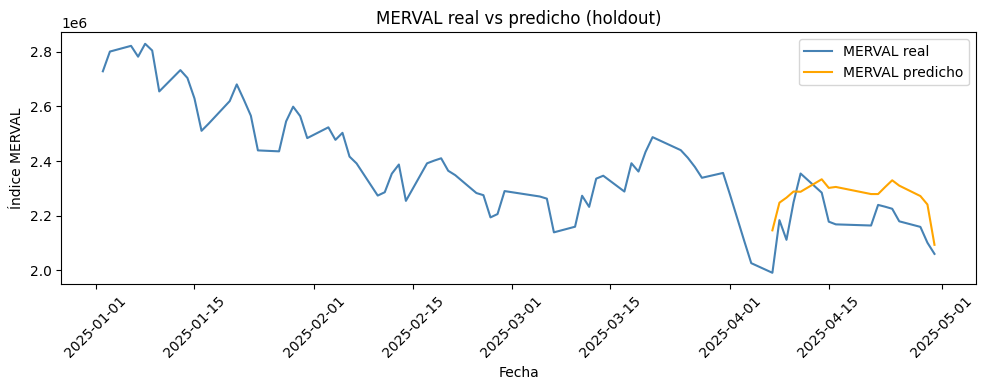

In [20]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


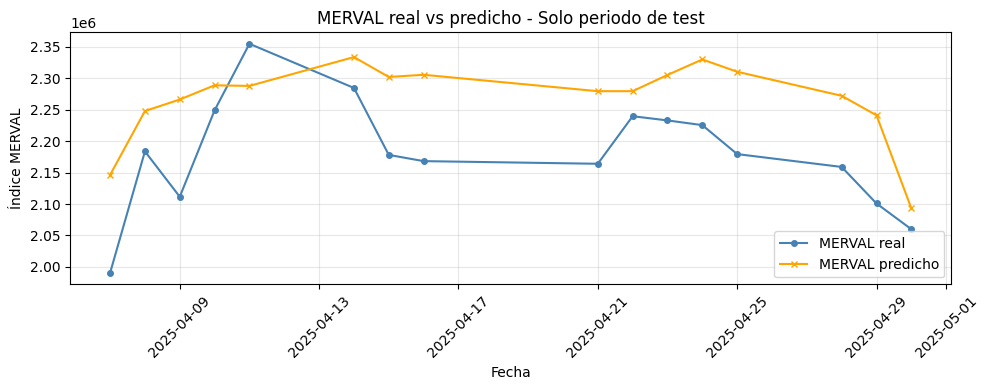

In [21]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test["fecha"], df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test["fecha"], df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

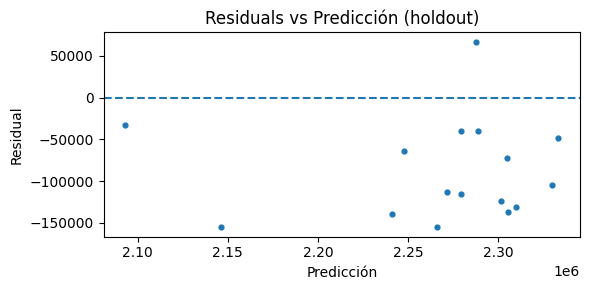

In [22]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


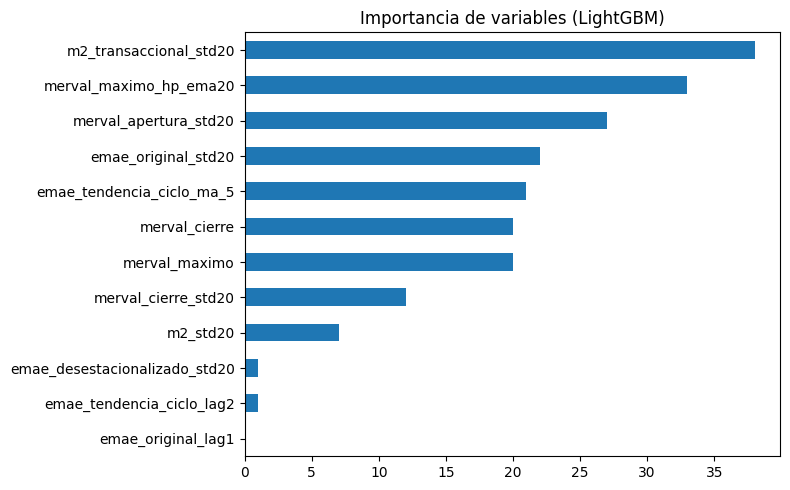

In [23]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8,5), title="Importancia de variables (LightGBM)")
plt.tight_layout()
plt.show()


## Modelos baseline adicionales para comparar

In [24]:
# Con tan pocos datos, es importante comparar contra baselines simples

# 1. Baseline: predicción con la media del train
from sklearn.dummy import DummyRegressor

baseline_mean = DummyRegressor(strategy="mean")
baseline_mean.fit(X_train, y_train)
y_pred_mean = baseline_mean.predict(X_test)

rmse_mean = root_mean_squared_error(y_test, y_pred_mean)
r2_mean = r2_score(y_test, y_pred_mean)

print("BASELINE - Predicción con media:")
print(f"  RMSE: {rmse_mean:.4f}")
print(f"  R²:   {r2_mean:.4f}")

# 2. Regresión lineal simple (Ridge con regularización)
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10.0)  # Regularización fuerte
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRIDGE REGRESSION:")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  R²:   {r2_ridge:.4f}")

# 3. LightGBM optimizado
print("\nLIGHTGBM OPTIMIZADO:")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f}")

# Comparación
print("\n" + "="*50)
print("COMPARACIÓN DE MODELOS:")
print("="*50)
results = pd.DataFrame({
    'Modelo': ['Baseline (Media)', 'Ridge Regression', 'LightGBM Optuna'],
    'RMSE': [rmse_mean, rmse_ridge, rmse],
    'R²': [r2_mean, r2_ridge, r2]
}).sort_values('RMSE')

print(results.to_string(index=False))

BASELINE - Predicción con media:
  RMSE: 269568.7703
  R²:   -8.9806

RIDGE REGRESSION:
  RMSE: 65514.3173
  R²:   0.4105

LIGHTGBM OPTIMIZADO:
  RMSE: 104957.0628
  R²:   -0.5130

COMPARACIÓN DE MODELOS:
          Modelo          RMSE        R²
Ridge Regression  65514.317322  0.410493
 LightGBM Optuna 104957.062761 -0.513003
Baseline (Media) 269568.770330 -8.980573
